# Лабораторна робота. Комп'ютерний практикум 2
## Задача 1, варіант 2. Рівняння Ріккаті → рівняння Бернуллі

Розв'язати рівняння:

$$x y' = y^2 - (2x+1)y + x^2 + 2x$$

---

### Стандартна форма рівняння Ріккаті

Ділимо обидві частини на $x$:

$$y' = \underbrace{\frac{1}{x}}_{P(x)}\,y^2 + \underbrace{\left(-2-\frac{1}{x}\right)}_{Q(x)}\,y + \underbrace{(x+2)}_{R(x)}$$

Це рівняння Ріккаті вигляду $y' = P(x)y^2 + Q(x)y + R(x)$.

---
## Крок 1. Підбір часткового розв'язку $y_1(x)$

Подивимось на вільний член $R(x) = x + 2$. Це поліном першого степеня, тому **спробуємо** $y_1 = x$ як найпростіший кандидат.

**Перевірка:** підставимо $y_1 = x$ у вихідне рівняння $xy' = y^2 - (2x+1)y + x^2 + 2x$:

$$\text{Ліва частина: } x \cdot 1 = x$$

$$\text{Права частина: } x^2 - (2x+1)x + x^2 + 2x = x^2 - 2x^2 - x + x^2 + 2x = x \checkmark$$

Підбір вдався:
$$\boxed{y_1(x) = x}$$

In [13]:
from sympy import *

x = symbols('x')
y = Function('y')

# Вихідне рівняння у стандартній формі
ode = Eq(y(x).diff(x), y(x)**2/x - (2 + 1/x)*y(x) + x + 2)
print("Рівняння Ріккаті (стандартна форма):")
display(ode)

# Перевірка часткового розв'язку y1 = x
y1 = x
lhs = diff(y1, x)
rhs = y1**2/x - (2 + 1/x)*y1 + x + 2

print("\nПеревірка y₁ = x:")
print(f"  y₁'           = {lhs}")
print(f"  права частина = {simplify(rhs)}")
print(f"  Збігаються:   {simplify(lhs - rhs) == 0}  ✓")

Рівняння Ріккаті (стандартна форма):


Eq(Derivative(y(x), x), x - (2 + 1/x)*y(x) + 2 + y(x)**2/x)


Перевірка y₁ = x:
  y₁'           = 1
  права частина = 1
  Збігаються:   True  ✓


---
## Крок 2. Зведення до рівняння Бернуллі

За теорією: якщо відомий частинний розв'язок $y_1$, то заміна
$$y = z + y_1(x) = z + x, \quad z = z(x)$$
зводить рівняння Ріккаті до **рівняння Бернуллі**.

Тоді $y' = z' + 1$. Підставляємо у $y' = \dfrac{1}{x}y^2 - \left(2+\dfrac{1}{x}\right)y + x+2$:

$$z' + 1 = \frac{(z+x)^2}{x} - \left(2+\frac{1}{x}\right)(z+x) + x+2$$

Розкриємо і згрупуємо:

$$z' + 1 = \frac{z^2}{x} + 2z + x - 2z - \frac{z}{x} - 2x - 1 + x + 2$$

$$z' + 1 = \frac{z^2}{x} - \frac{z}{x} + 1$$

Доданок $1$ скорочується з обох частин:

$$\boxed{z' = \frac{1}{x}z^2 - \frac{1}{x}z}$$

Це **рівняння Бернуллі** з $n = 2$:
$$z' + p(x)\,z = q(x)\,z^2, \quad p(x) = -\frac{1}{x},\quad q(x) = \frac{1}{x}$$

In [14]:
z = Function('z')

# Підстановка y = z + x 
y_sub = z(x) + x
dy_sub = diff(y_sub, x)          # z' + 1
rhs_sub = y_sub**2/x - (2 + 1/x)*y_sub + x + 2

# Рівняння для z
eq_z = simplify(dy_sub - rhs_sub)   # має дорівнювати 0 після перенесення

bernoulli = Eq(z(x).diff(x), z(x)**2/x - z(x)/x)
print("Рівняння Бернуллі (після заміни y = z + x):")
display(bernoulli)
print("\nСтупінь нелінійності n = 2")

Рівняння Бернуллі (після заміни y = z + x):


Eq(Derivative(z(x), x), z(x)**2/x - z(x)/x)


Ступінь нелінійності n = 2


---
## Крок 3. Розв'язання рівняння Бернуллі

Рівняння Бернуллі: $z' = \dfrac{z^2}{x} - \dfrac{z}{x}$

**Стандартна заміна** для рівняння Бернуллі при $n=2$:
$$u = z^{1-n} = z^{-1} = \frac{1}{z}$$

Тоді $u' = -\dfrac{z'}{z^2}$. Ділимо рівняння Бернуллі на $z^2$:

$$\frac{z'}{z^2} = \frac{1}{x} - \frac{1}{xz} \implies -u' = \frac{1}{x} - \frac{u}{x}$$

Отримали **лінійне рівняння** для $u$:
$$u' - \frac{u}{x} = -\frac{1}{x}$$

**Інтегруючий множник:** $\mu = e^{-\int \frac{dx}{x}} = \dfrac{1}{x}$

$$\frac{d}{dx}\!\left(\frac{u}{x}\right) = -\frac{1}{x^2} \implies \frac{u}{x} = \frac{1}{x} + C$$

$$u = 1 + Cx \implies z = \frac{1}{u} = \frac{1}{1+Cx}$$

In [15]:
u = Function('u')

# Лінійне рівняння для u = 1/z
ode_linear = Eq(u(x).diff(x) - u(x)/x, -1/x)
print("Лінійне рівняння після заміни u = 1/z:")
display(ode_linear)

sol_u = dsolve(ode_linear, u(x))
print("\nРозв'язок для u:")
display(sol_u)

C1 = symbols('C1')
z_sol = 1 / (1 + C1*x)
print("\nРозв'язок для z = 1/u:")
display(Eq(symbols('z'), z_sol))

Лінійне рівняння після заміни u = 1/z:


Eq(Derivative(u(x), x) - u(x)/x, -1/x)


Розв'язок для u:


Eq(u(x), C1*x + 1)


Розв'язок для z = 1/u:


Eq(z, 1/(C1*x + 1))

---
## Крок 4. Повернення до змінної $y$

Оскільки $y = z + x$ і $z = \dfrac{1}{1+Cx}$:

$$\boxed{y = x + \frac{1}{1+Cx}, \quad C \in \mathbb{R}}$$

> При $C = 0$: $y = x + 1$ — окремий розв'язок  
> При $z \to 0$: $y \to x = y_1$ — початковий частковий розв'язок

In [16]:
y_general = x + 1/(1 + C1*x)
print("Загальний розв'язок рівняння Ріккаті:")
display(Eq(y(x), y_general))

# Перевірка у вихідному рівнянні  x*y' = y² - (2x+1)y + x²+2x
lhs_check = x * diff(y_general, x)
rhs_check = y_general**2 - (2*x+1)*y_general + x**2 + 2*x
residual = simplify(lhs_check - rhs_check)
print(f"\nПеревірка: {residual}  ← має бути 0 ✓")

Загальний розв'язок рівняння Ріккаті:


Eq(y(x), x + 1/(C1*x + 1))


Перевірка: 0  ← має бути 0 ✓


---
## Крок 5. Автоматичний розв'язок через SymPy (dsolve)

In [17]:
ode_full = Eq(x * y(x).diff(x), y(x)**2 - (2*x+1)*y(x) + x**2 + 2*x)
print("Вихідне рівняння:")
display(ode_full)

sol_full = dsolve(ode_full, y(x))
print("\nЗагальний розв'язок (dsolve):")
display(sol_full)

Вихідне рівняння:


Eq(x*Derivative(y(x), x), x**2 + 2*x - (2*x + 1)*y(x) + y(x)**2)


Загальний розв'язок (dsolve):


Eq(y(x), (C1*x + C1 + x**2)/(C1 + x))

---
## Крок 6. Графічна візуалізація

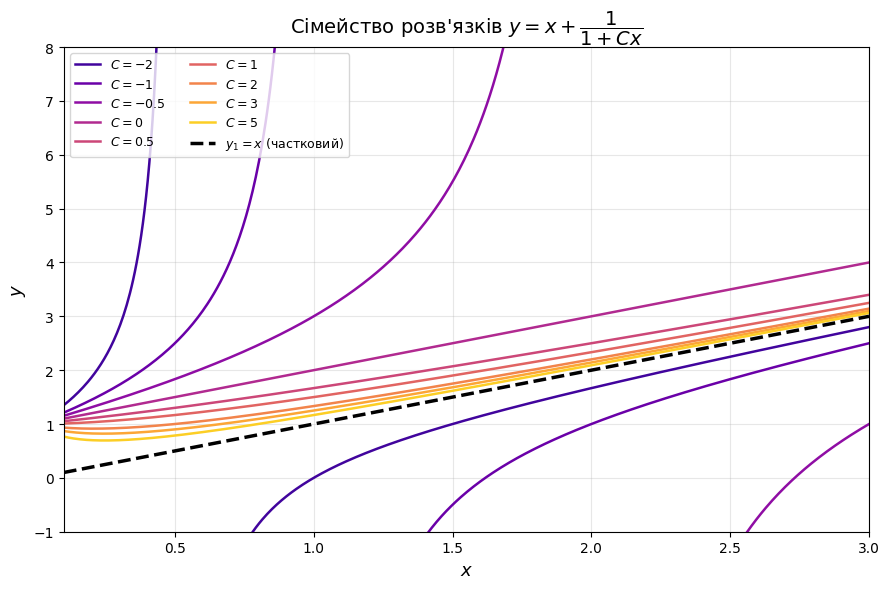

In [18]:
import numpy as np
import matplotlib.pyplot as plt

x_vals = np.linspace(0.1, 3, 500)
fig, ax = plt.subplots(figsize=(9, 6))

C_values = [-2, -1, -0.5, 0, 0.5, 1, 2, 3, 5]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(C_values)))

for i, C in enumerate(C_values):
    denom = 1 + C * x_vals
    with np.errstate(divide='ignore', invalid='ignore'):
        y_vals = x_vals + np.where(np.abs(denom) > 0.05, 1/denom, np.nan)
    ax.plot(x_vals, y_vals, color=colors[i], lw=1.8, label=f'$C = {C}$')

ax.plot(x_vals, x_vals, 'k--', lw=2.5, label='$y_1 = x$ (частковий)')

ax.set_xlim(0.1, 3)
ax.set_ylim(-1, 8)
ax.set_xlabel('$x$', fontsize=13)
ax.set_ylabel('$y$', fontsize=13)
ax.set_title(r"Сімейство розв'язків $y = x + \dfrac{1}{1+Cx}$", fontsize=14)
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Poshtak_lab_2_1.png', dpi=150)
plt.show()

---
## Підсумок

| Крок | Дія | Результат |
|:----:|-----|-----------|
| 1 | Стандартна форма Ріккаті | $y' = \frac{1}{x}y^2 - \frac{2x+1}{x}y + x+2$ |
| 2 | Підбір часткового розв'язку | $y_1 = x$ ✓ |
| 3 | Заміна $y = z + x$ (теорія п.3) | **Рівняння Бернуллі:** $z' = \frac{z^2}{x} - \frac{z}{x}$ |
| 4 | Заміна $u = 1/z$ (стандарт Бернуллі) | Лінійне: $u' - \frac{u}{x} = -\frac{1}{x}$ |
| 5 | Інтегруючий множник $\mu = 1/x$ | $u = 1 + Cx$ |
| 6 | Повернення $z=1/u$, $y=z+x$ | $y = x + \dfrac{1}{1+Cx}$ |

### Відповідь:

$$\boxed{y = x + \dfrac{1}{1 + Cx}, \quad C \in \mathbb{R}}$$